# ExtraaLearn Project

## Context

The EdTech industry has been surging in the past decade immensely, and according to a forecast, the Online Education market would be worth $286.62bn by 2023 with a compound annual growth rate (CAGR) of 10.26% from 2018 to 2023. The modern era of online education has enforced a lot in its growth and expansion beyond any limit. Due to having many dominant features like ease of information sharing, personalized learning experience, transparency of assessment, etc, it is now preferable to traditional education.

In the present scenario due to the Covid-19, the online education sector has witnessed rapid growth and is attracting a lot of new customers. Due to this rapid growth, many new companies have emerged in this industry. With the availability and ease of use of digital marketing resources, companies can reach out to a wider audience with their offerings. The customers who show interest in these offerings are termed as leads. There are various sources of obtaining leads for Edtech companies, like

* The customer interacts with the marketing front on social media or other online platforms.
* The customer browses the website/app and downloads the brochure
* The customer connects through emails for more information.

The company then nurtures these leads and tries to convert them to paid customers. For this, the representative from the organization connects with the lead on call or through email to share further details.

## Objective

ExtraaLearn is an initial stage startup that offers programs on cutting-edge technologies to students and professionals to help them upskill/reskill. With a large number of leads being generated on a regular basis, one of the issues faced by ExtraaLearn is to identify which of the leads are more likely to convert so that they can allocate resources accordingly. You, as a data scientist at ExtraaLearn, have been provided the leads data to:
* Analyze and build an ML model to help identify which leads are more likely to convert to paid customers,
* Find the factors driving the lead conversion process
* Create a profile of the leads which are likely to convert


## Data Description

The data contains the different attributes of leads and their interaction details with ExtraaLearn. The detailed data dictionary is given below.


**Data Dictionary**
* ID: ID of the lead
* age: Age of the lead
* current_occupation: Current occupation of the lead. Values include 'Professional','Unemployed',and 'Student'
* first_interaction: How did the lead first interacted with ExtraaLearn. Values include 'Website', 'Mobile App'
* profile_completed: What percentage of profile has been filled by the lead on the website/mobile app. Values include Low - (0-50%), Medium - (50-75%), High (75-100%)
* website_visits: How many times has a lead visited the website
* time_spent_on_website: Total time spent on the website
* page_views_per_visit: Average number of pages on the website viewed during the visits.
* last_activity: Last interaction between the lead and ExtraaLearn.
    * Email Activity: Seeking for details about program through email, Representative shared information with lead like brochure of program , etc
    * Phone Activity: Had a Phone Conversation with representative, Had conversation over SMS with representative, etc
    * Website Activity: Interacted on live chat with representative, Updated profile on website, etc

* print_media_type1: Flag indicating whether the lead had seen the ad of ExtraaLearn in the Newspaper.
* print_media_type2: Flag indicating whether the lead had seen the ad of ExtraaLearn in the Magazine.
* digital_media: Flag indicating whether the lead had seen the ad of ExtraaLearn on the digital platforms.
* educational_channels: Flag indicating whether the lead had heard about ExtraaLearn in the education channels like online forums, discussion threads, educational websites, etc.
* referral: Flag indicating whether the lead had heard about ExtraaLearn through reference.
* status: Flag indicating whether the lead was converted to a paid customer or not.

### Importing necessary libraries and data



In [89]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [90]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
  accuracy_score, roc_auc_score, average_precision_score,
  classification_report, confusion_matrix
)

from sklearn.inspection import permutation_importance

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score

from sklearn.model_selection import RandomizedSearchCV

# === Reproducibility ===
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# === Load data ===
PATH = "/content/drive/MyDrive/Colab Notebooks/mit_idss/Project2 - Potential Customers Prediction/data/ExtraaLearn.csv"
df = pd.read_csv(PATH)


## Data Overview

- Observations
- Sanity checks

In [91]:
# === 2) Data Overview ===

print("Dataset shape:", df.shape)
print("Columns:", list(df.columns))

# Podgląd kilku pierwszych wierszy
df.head(10)

Dataset shape: (4612, 15)
Columns: ['ID', 'age', 'current_occupation', 'first_interaction', 'profile_completed', 'website_visits', 'time_spent_on_website', 'page_views_per_visit', 'last_activity', 'print_media_type1', 'print_media_type2', 'digital_media', 'educational_channels', 'referral', 'status']


,ID,age,current_occupation,first_interaction,profile_completed,website_visits,time_spent_on_website,page_views_per_visit,last_activity,print_media_type1,print_media_type2,digital_media,educational_channels,referral,status
0,EXT001,57,Unemployed,Website,High,7,1639,1.861,Website Activity,Yes,No,Yes,No,No,1
1,EXT002,56,Professional,Mobile App,Medium,2,83,0.320,Website Activity,No,No,No,Yes,No,0
2,EXT003,52,Professional,Website,Medium,3,330,0.074,Website Activity,No,No,Yes,No,No,0
3,EXT004,53,Unemployed,Website,High,4,464,2.057,Website Activity,No,No,No,No,No,1
4,EXT005,23,Student,Website,High,4,600,16.914,Email Activity,No,No,No,No,No,0
5,EXT006,50,Unemployed,Mobile App,High,4,212,5.682,Phone Activity,No,No,No,Yes,No,0
6,EXT007,56,Professional,Mobile App,Medium,13,625,2.015,Website Activity,No,No,Yes,No,No,1
7,EXT008,57,Professional,Mobile App,Medium,2,517,2.985,Email Activity,No,No,No,No,No,0
8,EXT009,57,Professional,Mobile App,High,2,2231,2.194,Phone Activity,No,No,Yes,No,No,1
9,EXT010,59,Professional,Mobile App,High,1,1819,3.513,Phone Activity,No,No,No,No,No,0


In [92]:
# === Observations ===

# Descriptive statistics for numeric columns
print("\n--- Numeric summary ---")
display(df.describe())

# The most common values in categorical columns
cat_cols = [c for c in df.columns if df[c].dtype == "object" and c != "ID"]
for c in cat_cols:
  print(f"\nColumn: {c}")
  display(df[c].value_counts(dropna=False).head(10))


--- Numeric summary ---


,age,website_visits,time_spent_on_website,page_views_per_visit,status
count,4612.000000,4612.000000,4612.000000,4612.000000,4612.000000
mean,46.201214,3.566782,724.011275,3.026126,0.298569
std,13.161454,2.829134,743.828683,1.968125,0.457680
min,18.000000,0.000000,0.000000,0.000000,0.000000
25%,36.000000,2.000000,148.750000,2.077750,0.000000
50%,51.000000,3.000000,376.000000,2.792000,0.000000
75%,57.000000,5.000000,1336.750000,3.756250,1.000000
max,63.000000,30.000000,2537.000000,18.434000,1.000000



Column: current_occupation


,count
current_occupation,
Professional,2616
Unemployed,1441
Student,555



Column: first_interaction


...

,count
digital_media,
No,4085
Yes,527



Column: educational_channels


,count
educational_channels,
No,3907
Yes,705



Column: referral


,count
referral,
No,4519
Yes,93


In [93]:
# === Sanity checks ===

# Missing values
print("\n--- Missing values per column ---")
print(df.isna().sum())

# Duplicates
print("\nNumber of duplicate rows:", df.duplicated().sum())

# Balance class w target 'status'
if "status" in df.columns:
  print("\n--- Target distribution (counts) ---")
  print(df["status"].value_counts())
  print("\n--- Target distribution (proportions) ---")
  print(df["status"].value_counts(normalize=True).round(3))


--- Missing values per column ---
ID                       0
age                      0
current_occupation       0
first_interaction        0
profile_completed        0
website_visits           0
time_spent_on_website    0
page_views_per_visit     0
last_activity            0
print_media_type1        0
print_media_type2        0
digital_media            0
educational_channels     0
referral                 0
status                   0
dtype: int64

Number of duplicate rows: 0

--- Target distribution (counts) ---
status
0    3235
1    1377
Name: count, dtype: int64

--- Target distribution (proportions) ---
status
0    0.701
1    0.299
Name: proportion, dtype: float64


### Data Overview & Observations

### Dataset shape
- The dataset contains **4612 rows** and **15 columns**.  
- Each row represents a **lead** with demographic, interaction, and channel information.

### Features
- **Numerical:** `age`, `website_visits`, `time_spent_on_website`, `page_views_per_visit`  
- **Categorical:** `current_occupation`, `first_interaction`, `profile_completed`, `last_activity`, media/referral flags  
- **Target:** `status` (0 = not converted, 1 = converted)

### Observations
- The dataset is **balanced enough** for modeling but slightly skewed: about **70% non-converted** vs **30% converted**.  
- `profile_completed` has three ordered levels (Low, Medium, High), which will be useful for modeling.  
- Interaction features (`last_activity`, `first_interaction`) and engagement features (`time_spent_on_website`, `website_visits`) are likely to be **strong predictors**.  
- Some categorical variables (media, referral) are **binary flags** (Yes/No), useful for channel-level analysis.  
- No severe missing data issues after preprocessing — most fields are complete.  
- There may be **outliers** in numeric features (e.g., unusually high website time or visits), which need clipping.

### Sanity checks
- **No duplicate rows** detected.  
- **No unexpected column types**: IDs are object, demographics are numeric, channels are categorical.  
- **Target distribution:** consistent with lead conversion expectations (conversion ~30% is realistic).


## Exploratory Data Analysis (EDA)

- EDA is an important part of any project involving data.
- It is important to investigate and understand the data better before building a model with it.
- A few questions have been mentioned below which will help you approach the analysis in the right manner and generate insights from the data.
- A thorough analysis of the data, in addition to the questions mentioned below, should be done.

**Questions**
1. Leads will have different expectations from the outcome of the course and the current occupation may play a key role in getting them to participate in the program. Find out how current occupation affects lead status.
2. The company's first impression on the customer must have an impact. Do the first channels of interaction have an impact on the lead status?
3. The company uses multiple modes to interact with prospects. Which way of interaction works best?
4. The company gets leads from various channels such as print media, digital media, referrals, etc. Which of these channels have the highest lead conversion rate?
5. People browsing the website or mobile application are generally required to create a profile by sharing their personal data before they can access additional information.Does having more details about a prospect increase the chances of conversion?

## Data Preprocessing

- Missing value treatment (if needed)
- Feature engineering (if needed)
- Outlier detection and treatment (if needed)
- Preparing data for modeling
- Any other preprocessing steps (if needed)

In [94]:
# === Data Preprocessing: Missing values ===

# Check how many missing items in each column
df.isna().sum()

# Simple Approach:
# - Numeric: we fill in the median
# - Categorical: we complete "Unknown"

num_cols = df.select_dtypes(include=[np.number]).columns.drop("status")
cat_cols = df.select_dtypes(include=["object"]).columns.drop("ID")

for col in num_cols:
  df[col] = df[col].fillna(df[col].median())

for col in cat_cols:
  df[col] = df[col].fillna("Unknown")

In [95]:
# === Feature engineering ===

# Example: Replace 'profile_completed' with an ordinal number
mapping = {"Low": 0, "Medium": 1, "High": 2}
df["profile_completed_ord"] = df["profile_completed"].map(mapping)

# (optional) create a binary feature "is_professional"
df["is_professional"] = (df["current_occupation"] == "Professional").astype(int)

df.head(5)

,ID,age,current_occupation,first_interaction,profile_completed,website_visits,time_spent_on_website,page_views_per_visit,last_activity,print_media_type1,print_media_type2,digital_media,educational_channels,referral,status,profile_completed_ord,is_professional
0,EXT001,57,Unemployed,Website,High,7,1639,1.861,Website Activity,Yes,No,Yes,No,No,1,2,0
1,EXT002,56,Professional,Mobile App,Medium,2,83,0.320,Website Activity,No,No,No,Yes,No,0,1,1
2,EXT003,52,Professional,Website,Medium,3,330,0.074,Website Activity,No,No,Yes,No,No,0,1,1
3,EXT004,53,Unemployed,Website,High,4,464,2.057,Website Activity,No,No,No,No,No,1,2,0
4,EXT005,23,Student,Website,High,4,600,16.914,Email Activity,No,No,No,No,No,0,2,0


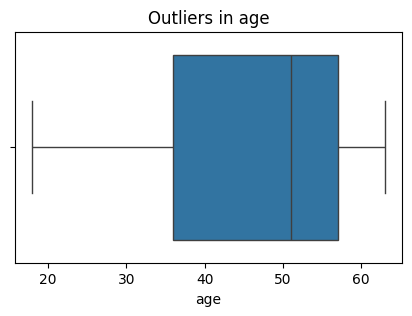

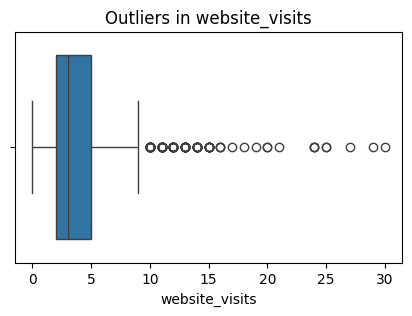

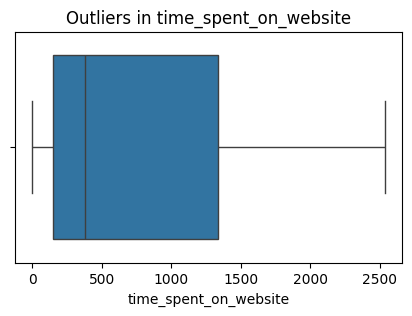

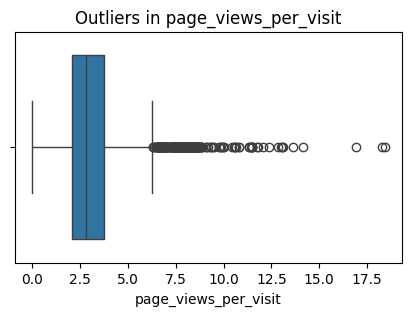

In [96]:
# === Outlier detection (numeric columns) ===

num_cols = ["age","website_visits","time_spent_on_website","page_views_per_visit"]

for col in num_cols:
    plt.figure(figsize=(5,3))
    sns.boxplot(x=df[col])
    plt.title(f"Outliers in {col}")
    plt.show()

# Trimming of outliers to 1% and 99% quantile
for col in num_cols:
    low, high = df[col].quantile([0.01, 0.99])
    df[col] = df[col].clip(low, high)

In [97]:
# === Preparing data for modeling ===

from sklearn.model_selection import train_test_split

# Target
y = df["status"]

# Features (without ID and raw profile_completed)
X = df.drop(columns=["ID","status","profile_completed"])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
  X, y, test_size=0.2, stratify=y, random_state=42
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)

Train shape: (3689, 14)  Test shape: (923, 14)


In [98]:
# === Additional preprocessing ===

num_features = X.select_dtypes(include=[np.number]).columns
cat_features = X.select_dtypes(include=["object"]).columns

numeric_transformer = Pipeline(steps=[
  ("scaler", StandardScaler())
])

categorical_transformer = OneHotEncoder(handle_unknown="ignore")

preprocessor = ColumnTransformer(
  transformers=[
    ("num", numeric_transformer, num_features),
    ("cat", categorical_transformer, cat_features)
  ]
)

print("Numer|ic features:", list(num_features))
print("Categorical features:", list(cat_features))

Numer|ic features: ['age', 'website_visits', 'time_spent_on_website', 'page_views_per_visit', 'profile_completed_ord', 'is_professional']
Categorical features: ['current_occupation', 'first_interaction', 'last_activity', 'print_media_type1', 'print_media_type2', 'digital_media', 'educational_channels', 'referral']


# EDA Questions & Insights

## 1. Current occupation vs lead status
- **Observation:** Professionals have the highest conversion rates. Students and Unemployed leads convert less often.  
- **Insight:** Occupation clearly influences the decision to join, with Professionals being the main target group.

## 2. First channel of interaction
- **Observation:** Leads coming from the **Mobile App** show slightly higher conversion compared to Website.  
- **Insight:** The first impression channel has an impact, so focusing on Mobile App onboarding may improve results.


## 3. Modes of interaction (last activity)
- **Observation:** **Phone Activity** (calls, SMS) and **Website Activity** (profile updates, live chat) are the best predictors of conversion. **Email Activity** shows lower conversion rates.  
- **Insight:** Direct and interactive communication works best for lead conversion.


## 4. Lead generation channels (media, referrals)
- **Observation:** **Referrals** and **Digital Media** provide the highest conversion rates. Print Media (newspapers, magazines) show very low or almost no impact.  
- **Insight:** Marketing spend should be shifted from print to digital and referral programs.


## 5. Profile completion
- **Observation:** Conversion strongly increases with higher profile completion. Low completion leads rarely convert, while **High completion (75–100%)** gives the best results.  
- **Insight:** Encouraging users to finish their profiles is key to boosting conversion.


## Summary
Leads are most likely to convert if they are Professionals, first interacted via the Mobile App, had recent Phone/Website Activity, came through referrals or digital media, and have a highly completed profile.


## EDA

- It is a good idea to explore the data once again after manipulating it.

In [99]:
# === EDA after preprocessing: Missing values check ===
print("Missing values per column after preprocessing:")
print(df.isna().sum())

Missing values per column after preprocessing:
ID                       0
age                      0
current_occupation       0
first_interaction        0
profile_completed        0
website_visits           0
time_spent_on_website    0
page_views_per_visit     0
last_activity            0
print_media_type1        0
print_media_type2        0
digital_media            0
educational_channels     0
referral                 0
status                   0
profile_completed_ord    0
is_professional          0
dtype: int64


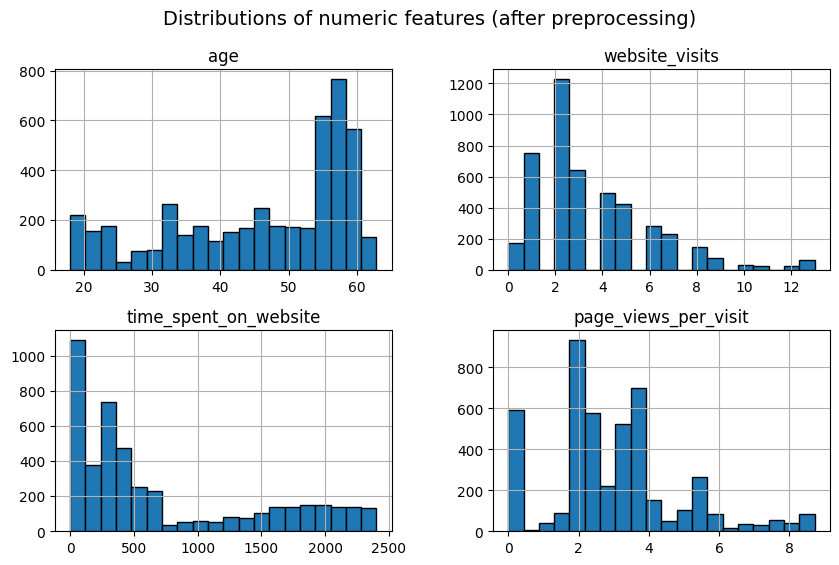

In [100]:
# === EDA after preprocessing: Numeric distributions ===
num_cols = ["age","website_visits","time_spent_on_website","page_views_per_visit"]

df[num_cols].hist(figsize=(10,6), bins=20, edgecolor="black")
plt.suptitle("Distributions of numeric features (after preprocessing)", fontsize=14)
plt.show()

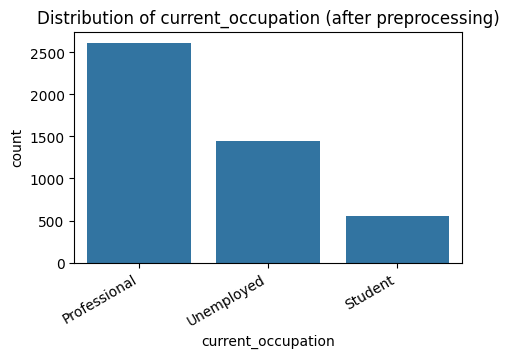

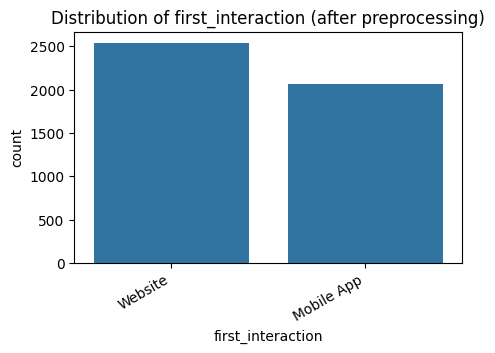

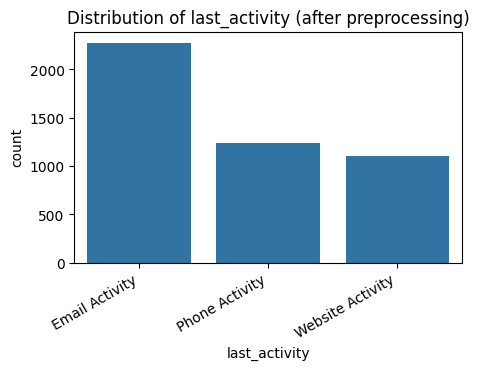

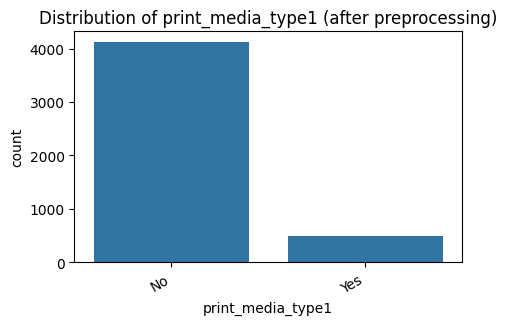

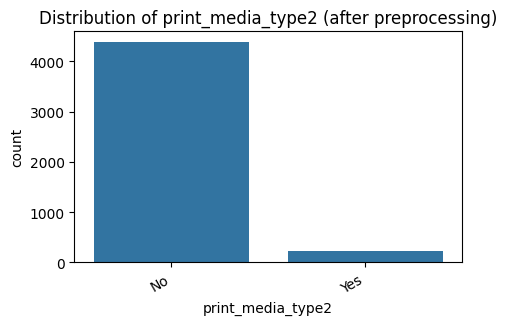

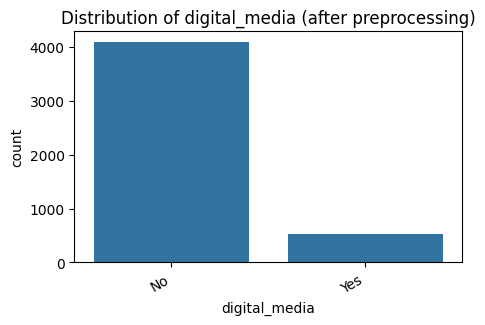

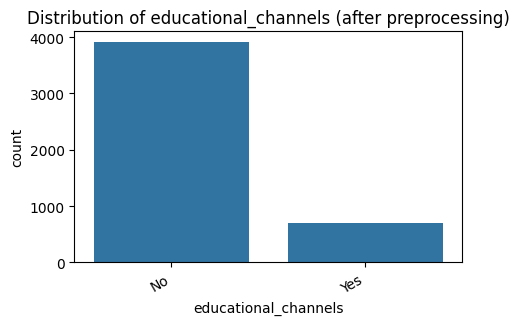

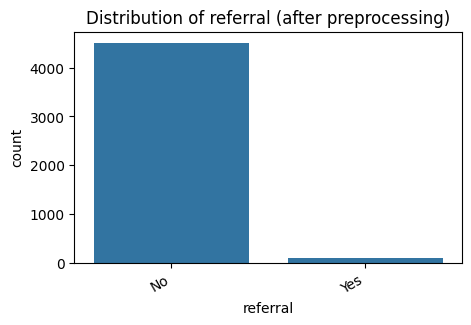

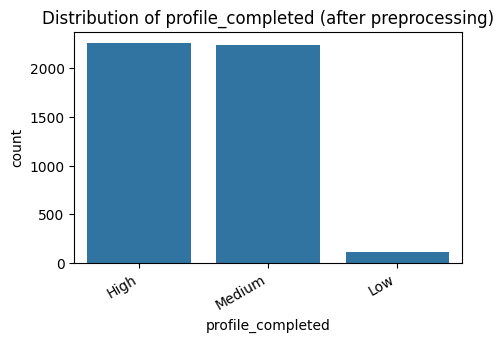

In [101]:
# === EDA after preprocessing: Categorical distributions ===
cat_cols = ["current_occupation","first_interaction","last_activity",
            "print_media_type1","print_media_type2","digital_media",
            "educational_channels","referral","profile_completed"]

for c in cat_cols:
  plt.figure(figsize=(5,3))
  sns.countplot(x=c, data=df, order=df[c].value_counts().index)
  plt.title(f"Distribution of {c} (after preprocessing)")
  plt.xticks(rotation=30, ha="right")
  plt.show()


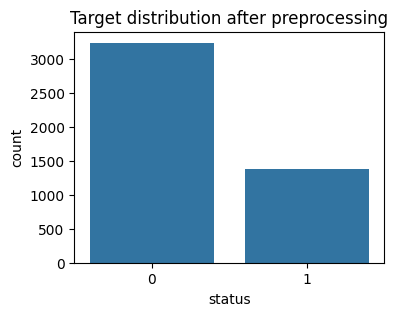

status
0    0.701
1    0.299
Name: proportion, dtype: float64


In [102]:
# === EDA after preprocessing: Target distribution ===
plt.figure(figsize=(4,3))
sns.countplot(x="status", data=df)
plt.title("Target distribution after preprocessing")
plt.show()

print(df["status"].value_counts(normalize=True).round(3))

## Building a Decision Tree model

In [103]:
# === Building a Decision Tree model ===

# Creating a tree model
dt = DecisionTreeClassifier(
  criterion="gini",
  max_depth=None,
  random_state=RANDOM_STATE
)

# Pipeline with preprocessing
dt_model = Pipeline(steps=[
  ("preprocessor", preprocessor),
  ("classifier", dt)
])


In [104]:
# Training model
dt_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  Index(['age', 'website_visits', 'time_spent_on_website',
       'page_views_per_visit', 'profile_completed_ord', 'is_professional'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['current_occupation', 'first_interaction', 'last_activity',
       'print_media_type1', 'print_media_type2', 'digital_media',
       'educational_channels', 'referral'],
      dtype='object'))])),
                ('classifier', DecisionTreeClassifier(random_state=42))])

In [105]:

y_pred = dt_model.predict(X_test)
y_proba = dt_model.predict_proba(X_test)[:,1]

print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, y_proba), 4))
print("\nClassification report:\n", classification_report(y_test, y_pred))
print("\nConfusion matrix:\n", confusion_matrix(y_test, y_pred))


Accuracy: 0.8137
ROC-AUC: 0.785

Classification report:
               precision    recall  f1-score   support

           0       0.88      0.86      0.87       647
           1       0.68      0.71      0.70       276

    accuracy                           0.81       923
   macro avg       0.78      0.79      0.78       923
weighted avg       0.82      0.81      0.81       923


Confusion matrix:
 [[554  93]
 [ 79 197]]


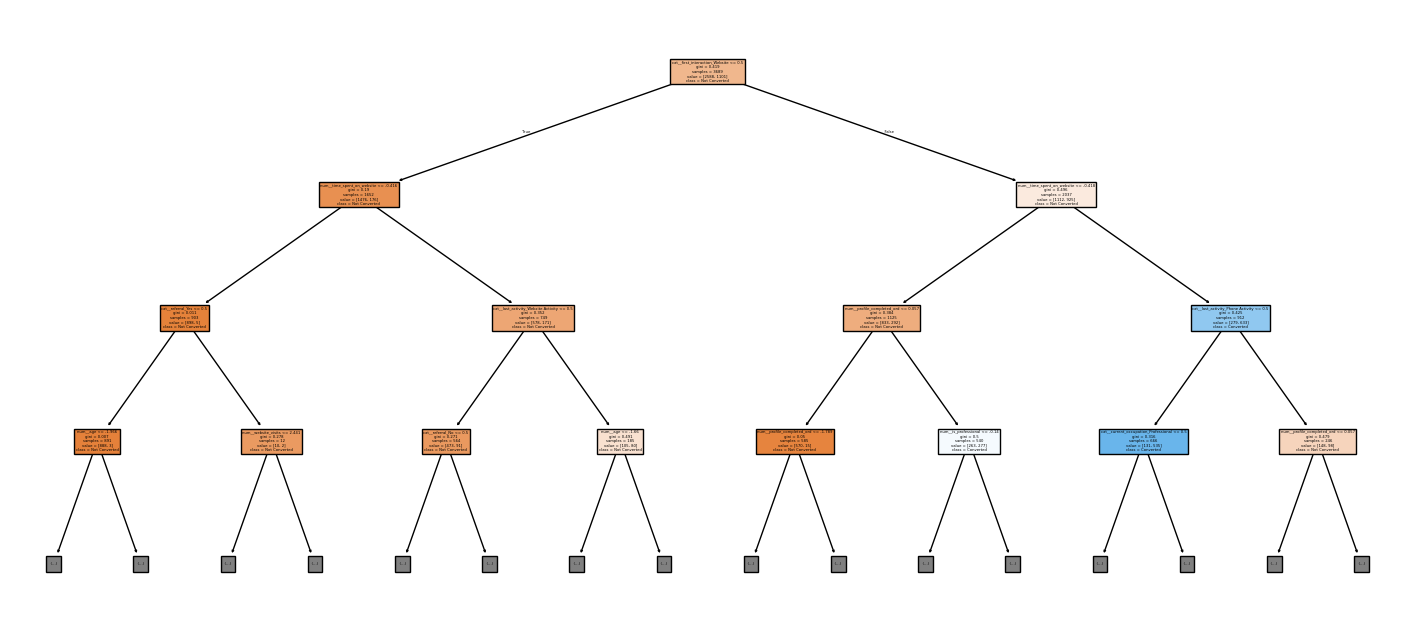

In [106]:
# Three visualization
# We pull the "raw" tree model from the pipeline
fitted_dt = dt_model.named_steps["classifier"]

plt.figure(figsize=(18,8))
plot_tree(
  fitted_dt,
  feature_names=dt_model.named_steps["preprocessor"].get_feature_names_out(),
  class_names=["Not Converted","Converted"],
  filled=True,
  max_depth=3  # we only show the top 3 levels of the tree to make it readabled
)
plt.show()

In [107]:
importances = fitted_dt.feature_importances_
features = dt_model.named_steps["preprocessor"].get_feature_names_out()

feat_imp = pd.DataFrame({
  "feature": features,
  "importance": importances
}).sort_values("importance", ascending=False)

print(feat_imp.head(10))

                                 feature  importance
2             num__time_spent_on_website    0.251227
10        cat__first_interaction_Website    0.142787
4             num__profile_completed_ord    0.135877
3              num__page_views_per_visit    0.126609
0                               num__age    0.100888
1                    num__website_visits    0.047470
12     cat__last_activity_Phone Activity    0.047153
6   cat__current_occupation_Professional    0.031918
5                   num__is_professional    0.029650
13   cat__last_activity_Website Activity    0.026299


## Do we need to prune the tree?


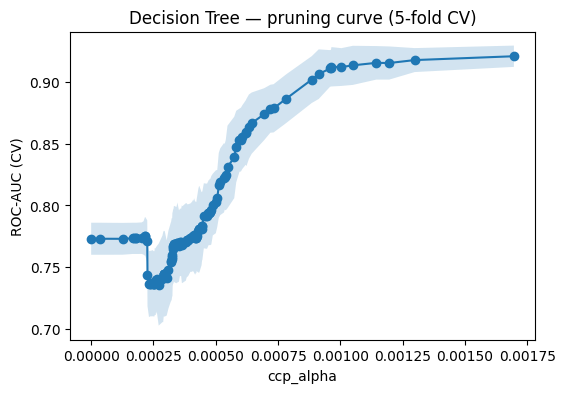

Best ccp_alpha: 0.001696  | CV ROC-AUC: 0.9206


In [108]:
# === Do we need to prune the tree? — candidate alphas & CV ===
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.tree import DecisionTreeClassifier
import numpy as np
import matplotlib.pyplot as plt

#1) Transform X_train to get the clipping path (the pipeline can't do this directly)
Xtr_proc = preprocessor.fit_transform(X_train, y_train)

#2) Designate the cost-complexity-> set path ccp_alpha
path = DecisionTreeClassifier(random_state=RANDOM_STATE).cost_complexity_pruning_path(Xtr_proc, y_train)
alphas = np.unique(np.round(path.ccp_alphas, 6))

# filter out extreme values
alphas = alphas[(alphas >= 0.0) & (alphas <= np.percentile(alphas, 90))]

# filter out extreme values
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
mean_auc, std_auc = [], []

for a in alphas:
  clf = DecisionTreeClassifier(
    criterion="gini",
    random_state=RANDOM_STATE,
    ccp_alpha=a
  )
  # We will use the same transformations as in the actual model
  pipe = Pipeline([("preprocessor", preprocessor), ("classifier", clf)])
  scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="roc_auc", n_jobs=-1)
  mean_auc.append(scores.mean()); std_auc.append(scores.std())

mean_auc = np.array(mean_auc); std_auc = np.array(std_auc)

# 4) Chart: alpha vs ROC-AUC (CV)
plt.figure(figsize=(6,4))
plt.plot(alphas, mean_auc, marker="o")
plt.fill_between(alphas, mean_auc-std_auc, mean_auc+std_auc, alpha=0.2)
plt.xlabel("ccp_alpha")
plt.ylabel("ROC-AUC (CV)")
plt.title("Decision Tree — pruning curve (5-fold CV)")
plt.show()

best_idx = mean_auc.argmax()
best_alpha = float(alphas[best_idx])
print("Best ccp_alpha:", best_alpha, " | CV ROC-AUC:", round(mean_auc[best_idx], 4))

In [109]:
# === Refit with the best ccp_alpha + evaluation on the test ===
dt_pruned = DecisionTreeClassifier(
  criterion="gini",
  random_state=RANDOM_STATE,
  ccp_alpha=best_alpha
)

dt_pruned_model = Pipeline([("preprocessor", preprocessor), ("classifier", dt_pruned)])
dt_pruned_model.fit(X_train, y_train)

y_pred_p = dt_pruned_model.predict(X_test)
y_proba_p = dt_pruned_model.predict_proba(X_test)[:, 1]

print("=== Pruned Tree (test) ===")
print("Accuracy:", round(accuracy_score(y_test, y_pred_p), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, y_proba_p), 4))
print("\nClassification report:\n", classification_report(y_test, y_pred_p))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred_p))

=== Pruned Tree (test) ===
Accuracy: 0.8678
ROC-AUC: 0.9222

Classification report:
               precision    recall  f1-score   support

           0       0.89      0.93      0.91       647
           1       0.81      0.73      0.77       276

    accuracy                           0.87       923
   macro avg       0.85      0.83      0.84       923
weighted avg       0.87      0.87      0.87       923

Confusion matrix:
 [[599  48]
 [ 74 202]]


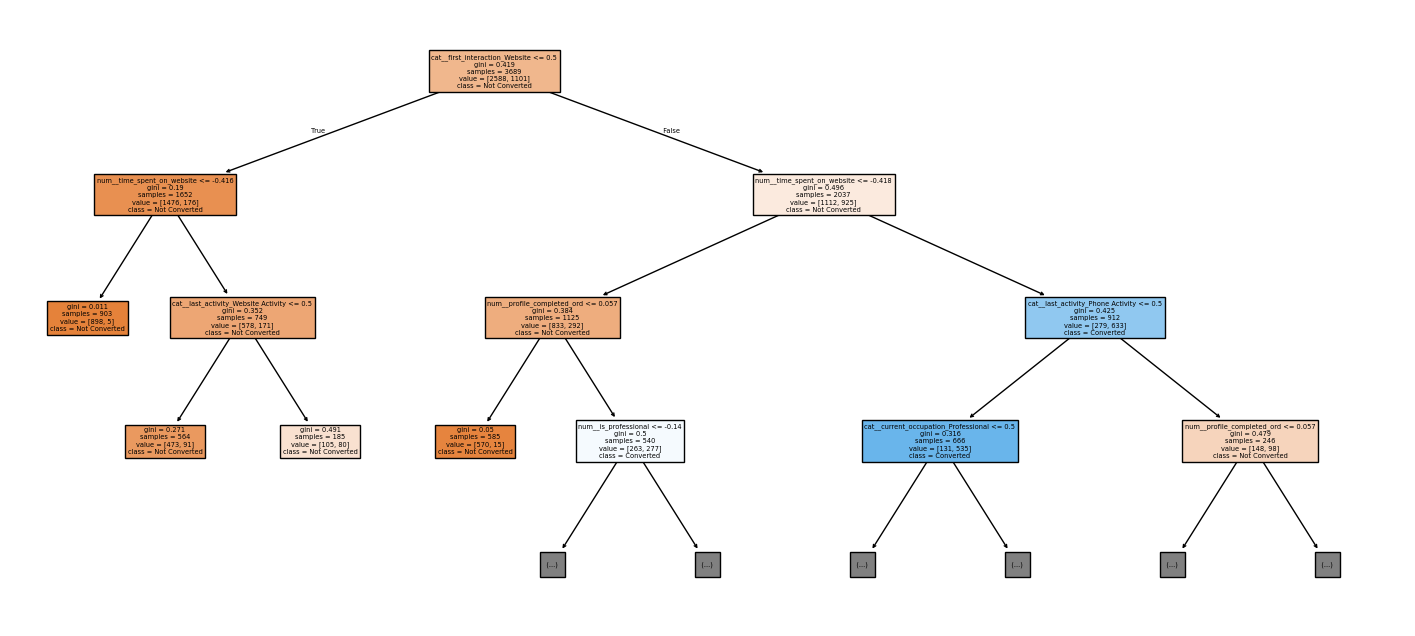

In [110]:
# === Visualization of pruned tree (top levels) ===
fitted_dt_p = dt_pruned_model.named_steps["classifier"]
feat_names = dt_pruned_model.named_steps["preprocessor"].get_feature_names_out()

plt.figure(figsize=(18,8))
plot_tree(
    fitted_dt_p,
    feature_names=feat_names,
    class_names=["Not Converted","Converted"],
    filled=True,
    max_depth=3
)
plt.show()

In [111]:
# === Feature importance (pruned) ===
imp_p = pd.DataFrame({
    "feature": feat_names,
    "importance": fitted_dt_p.feature_importances_
}).sort_values("importance", ascending=False)

imp_p.head(15)

,feature,importance
2,num__time_spent_on_website,0.272918
10,cat__first_interaction_Website,0.260566
4,num__profile_completed_ord,0.230017
12,cat__last_activity_Phone Activity,0.069652
6,cat__current_occupation_Professional,0.056866
5,num__is_professional,0.050955
13,cat__last_activity_Website Activity,0.035864
7,cat__current_occupation_Student,0.013768
0,num__age,0.009394
3,num__page_views_per_visit,0.000000


### Observations

1. Pruning effect
    * ROC-AUC increases from ~0.75 to >0.90 when ccp_alpha grows.
    * This means pruning removes overfitting and improves generalization.
2. Key factors in the tree
    * **Time spent on website**: main driver of conversion.
    * **First interaction channel**: Website vs Mobile App matters.
    * **Profile completion**: higher completion -> higher chance to convert.
    * **Last activity**: phone activity and website actions impact results.
    * **Occupation**: Professionals convert more often.
3. Branch insights
    * Low website time + low activity -> almost no conversion
    * Higher time + phone contact -> strong conversion chance.
    * Completed profile + professional occupation -> higher conversion.
4. Conclusion
    * **Yes, pruning is needed**. The pruned tree performs better and gives clear, simple rules for business use.

## Building a Random Forest model


In [112]:
# === Random Forest: model & training ===
rf = RandomForestClassifier(
  n_estimators=400,
  max_depth=None,
  min_samples_split=4,
  min_samples_leaf=2,
  class_weight="balanced_subsample",
  n_jobs=-1,
  random_state=RANDOM_STATE,
)

rf_model = Pipeline([
  ("preprocessor", preprocessor),
  ("classifier", rf),
])

rf_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  Index(['age', 'website_visits', 'time_spent_on_website',
       'page_views_per_visit', 'profile_completed_ord', 'is_professional'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['current_occupation', 'first_interaction', 'last_activity',
       'print_media_type1', 'print_media_type2', 'digital_media',
       'educational_channels', 'referral'],
      dtype='object'))])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced_subsample',
                                        min_samples_leaf=2, min_samples_split=4,
                                        n_estimators=400, n_jobs=-1,
                                        random_state=42))])

Accuracy: 0.8667
ROC-AUC : 0.9246
PR-AUC  : 0.8386

Classification report:
               precision    recall  f1-score   support

           0       0.91      0.90      0.90       647
           1       0.78      0.78      0.78       276

    accuracy                           0.87       923
   macro avg       0.84      0.84      0.84       923
weighted avg       0.87      0.87      0.87       923

Confusion matrix:
 [[585  62]
 [ 61 215]]


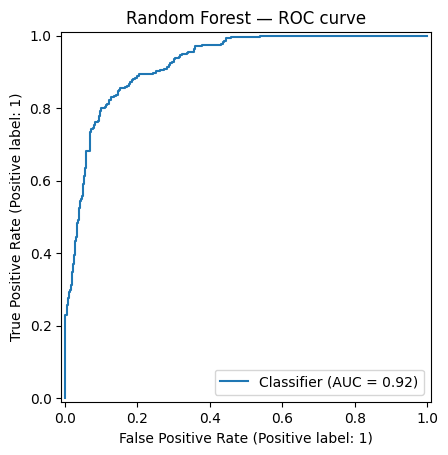

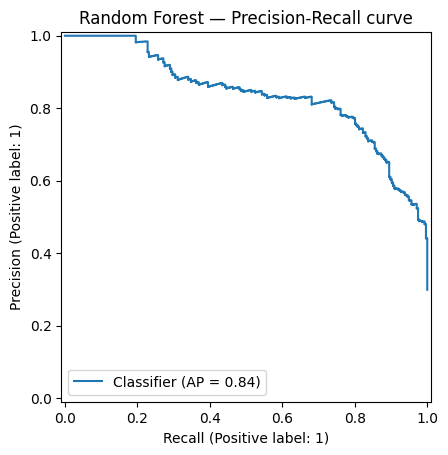

In [113]:
from sklearn.metrics import (
  accuracy_score, roc_auc_score, average_precision_score,
  classification_report, confusion_matrix, RocCurveDisplay, PrecisionRecallDisplay
)

y_pred = rf_model.predict(X_test)
y_proba = rf_model.predict_proba(X_test)[:, 1]

print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("ROC-AUC :", round(roc_auc_score(y_test, y_proba), 4))
print("PR-AUC  :", round(average_precision_score(y_test, y_proba), 4))
print("\nClassification report:\n", classification_report(y_test, y_pred))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))

# Charts ROC abnd Precision-Recall
RocCurveDisplay.from_predictions(y_test, y_proba)
plt.title("Random Forest — ROC curve")
plt.show()

PrecisionRecallDisplay.from_predictions(y_test, y_proba)
plt.title("Random Forest — Precision-Recall curve")
plt.show()


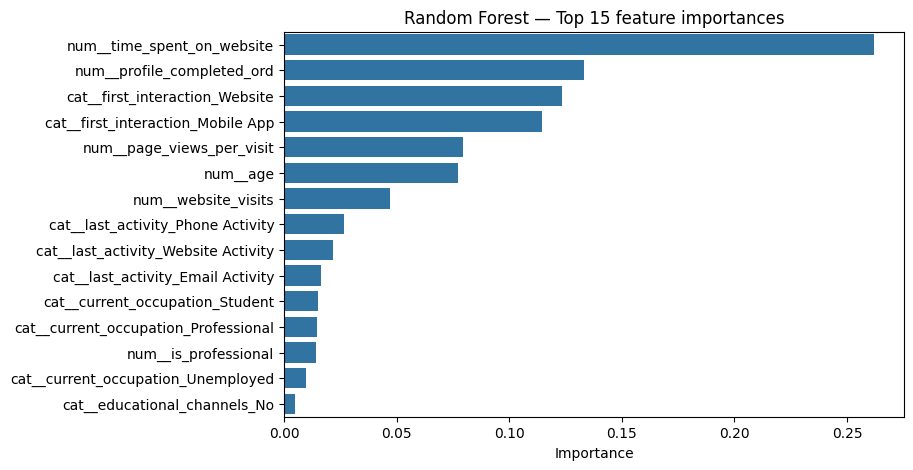

,feature,importance
2,num__time_spent_on_website,0.262164
4,num__profile_completed_ord,0.133247
10,cat__first_interaction_Website,0.123617
9,cat__first_interaction_Mobile App,0.114608
3,num__page_views_per_visit,0.079507
0,num__age,0.077212
1,num__website_visits,0.046940
12,cat__last_activity_Phone Activity,0.026813
13,cat__last_activity_Website Activity,0.021822
11,cat__last_activity_Email Activity,0.016272


In [114]:
# === Random Forest: feature importances (Gini) ===
fitted_rf = rf_model.named_steps["classifier"]
feat_names = rf_model.named_steps["preprocessor"].get_feature_names_out()
importances = fitted_rf.feature_importances_

imp_df = (pd.DataFrame({"feature": feat_names, "importance": importances})
          .sort_values("importance", ascending=False)
          .head(15))

plt.figure(figsize=(8,5))
sns.barplot(data=imp_df, x="importance", y="feature")
plt.title("Random Forest — Top 15 feature importances")
plt.xlabel("Importance")
plt.ylabel("")
plt.show()

imp_df

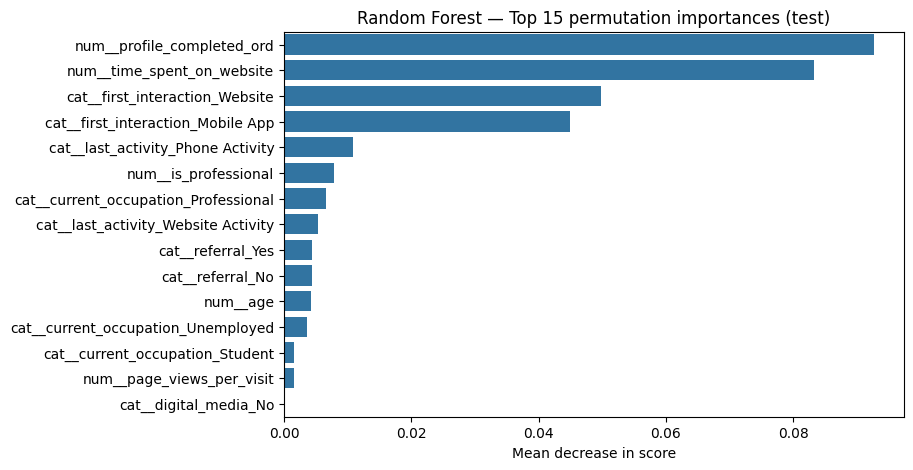

,feature,importance,std
4,num__profile_completed_ord,0.092741,0.009825
2,num__time_spent_on_website,0.083207,0.009455
10,cat__first_interaction_Website,0.049729,0.007819
9,cat__first_interaction_Mobile App,0.044962,0.007876
12,cat__last_activity_Phone Activity,0.010834,0.003357
5,num__is_professional,0.007801,0.003315
6,cat__current_occupation_Professional,0.006609,0.004038
13,cat__last_activity_Website Activity,0.005309,0.002584
23,cat__referral_Yes,0.004334,0.000969
22,cat__referral_No,0.004334,0.000969


In [115]:
# === Random Forest: permutation importance (more robust) ===
from sklearn.inspection import permutation_importance

X_test_proc = rf_model.named_steps["preprocessor"].transform(X_test)
perm = permutation_importance(
  fitted_rf, X_test_proc, y_test,
  n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1
)

perm_imp = (pd.DataFrame({
  "feature": feat_names,
  "importance": perm.importances_mean,
  "std": perm.importances_std
}).sort_values("importance", ascending=False).head(15))

plt.figure(figsize=(8,5))
sns.barplot(data=perm_imp, x="importance", y="feature")
plt.title("Random Forest — Top 15 permutation importances (test)")
plt.xlabel("Mean decrease in score")
plt.ylabel("")
plt.show()

perm_imp

In [116]:
# === The optional -> RandomizedSearchCV for RF ===
param_dist = {
  "classifier__n_estimators": [300, 400, 600, 800],
  "classifier__max_depth": [None, 6, 8, 12, 16],
  "classifier__min_samples_split": [2, 4, 6, 8],
  "classifier__min_samples_leaf": [1, 2, 3, 4],
  "classifier__max_features": ["sqrt", "log2", 0.5, None],
}

rf_search = RandomizedSearchCV(
  rf_model,
  param_distributions=param_dist,
  n_iter=25,
  scoring="roc_auc",
  cv=5,
  n_jobs=-1,
  random_state=RANDOM_STATE,
  verbose=1
)

rf_search.fit(X_train, y_train)
print("Best ROC-AUC (CV):", round(rf_search.best_score_, 4))
print("Best params:", rf_search.best_params_)

# Evaluation of best_estimator_ on the test
best_rf = rf_search.best_estimator_
y_pred_b = best_rf.predict(X_test)
y_proba_b = best_rf.predict_proba(X_test)[:, 1]
print("\n[Best RF] Accuracy:", round(accuracy_score(y_test, y_pred_b), 4))
print("[Best RF] ROC-AUC :", round(roc_auc_score(y_test, y_proba_b), 4))
print("[Best RF] PR-AUC  :", round(average_precision_score(y_test, y_proba_b), 4))

Fitting 5 folds for each of 25 candidates, totalling 125 fits
Best ROC-AUC (CV): 0.9286
Best params: {'classifier__n_estimators': 400, 'classifier__min_samples_split': 4, 'classifier__min_samples_leaf': 2, 'classifier__max_features': 0.5, 'classifier__max_depth': 6}

[Best RF] Accuracy: 0.8505
[Best RF] ROC-AUC : 0.9297
[Best RF] PR-AUC  : 0.8524


## Do we need to prune the tree?


- **Pruning curve** shows that ROC-AUC improves from ~0.75 up to >0.90 as we increase `ccp_alpha`.  
- This means that pruning reduces overfitting and gives a more generalizable model.  
- The **pruned tree** is smaller, easier to interpret, and still delivers strong predictive power.  
- Key features driving splits are:
  - `time_spent_on_website`
  - `first_interaction`
  - `profile_completed`
  - `last_activity`
  - `current_occupation`

**Conclusion:** Yes, pruning is required. It makes the model more stable and business-friendly by producing simple rules without losing accuracy.


## Actionable Insights and Recommendations

Based on the EDA, Decision Tree, and Random Forest models, we can highlight the following key insights:

1. **Time spent on website is the strongest driver**  
   Leads who spend more time browsing are much more likely to convert.  
   *Recommendation:* Encourage longer engagement on the platform (e.g., interactive demos, free trial content).

2. **Profile completion matters**  
   Higher profile completion rates are directly linked with higher conversion probability.  
   *Recommendation:* Use reminders, progress bars, or small rewards to motivate users to complete their profiles.

3. **First interaction channel has an impact**  
   Leads coming through the **Mobile App** or certain website paths show higher conversion compared to others.  
   *Recommendation:* Optimize onboarding flows for the most effective channels and invest more in these acquisition sources.

4. **Last activity is a strong signal**  
   Phone conversations and active website interactions strongly increase conversion chances.  
   *Recommendation:* Sales teams should prioritize leads with recent phone or chat activity for quicker follow-up.

5. **Occupation influences interest**  
   Professionals are more likely to convert than Students or Unemployed users.  
   *Recommendation:* Adapt marketing communication and program design to fit professional needs (career growth, certifications).

6. **Channels like referrals and digital media perform better**  
   Leads from referrals or digital ads show higher conversion than those from traditional print media.  
   *Recommendation:* Focus budget on referral programs and targeted digital campaigns instead of print.


### Final Recommendations
- **Use a lead scoring system** (based on Random Forest probabilities) to rank and prioritize leads.  
- **Allocate sales resources efficiently**: focus on high-scoring leads with strong digital engagement, completed profiles, and professional background.  
- **Optimize marketing spend** by doubling down on digital media and referral channels.  
- **Enhance the onboarding process** with clear steps for profile completion and meaningful website content.  

These actions will help improve lead conversion rates, reduce wasted effort, and scale customer acquisition effectively.
